# K-Means Clustering

K-Means clustering randomly initializes *k* cluster centroids in the dataset. Then, the algorithm measures the distance between  each cluster centroids and each data point in the data set. The distance metric used can be Euclidean or Manhattan distance. The data points are then assigned to the centroids that is closest to that point. 

When all points are assigned, new centroids of the cluster are located by averaging all the datapoints that are assigned to that cluster. The new centroids are then used to repeat the process (measure distance to all points, cluster point to closest centroids, computer new centroids, repeat). 

This process continues until a stopping condition is reached. The stopping condition is usually met when a certain number of iterations has been reached, or if the movement of the new centroids point is less than a specific threshold, or if the centroids stop moving. On data that have a structure that allows for clustering, k-means typically converges after a low number of iterations.

K-Means always requires declaring the number of clusters up front. Below, we will discuss methods for determining and optimal *k* value.

The following image summarizes K-means clustering: 1a. Randomly initialize *k* cluster centroids, 1b. Measure the distance between each point and the cluster 2. Group data points to the nearest cluster 3. Average the points in a cluster to find the new cluster centroid, repeat steps 1b to 3 until a stopping condition is reached.

<img src="kmeans_image.png" alt="The steps of K-means visualized" width="80%"/>

### Make random dataset

For this example, we will use a randomly generated dataset. Below, we generate this dataset using the SkiKit Learn methods.

 - 2267 fibres kept.
 - 128 fibres removed


KeyboardInterrupt: 

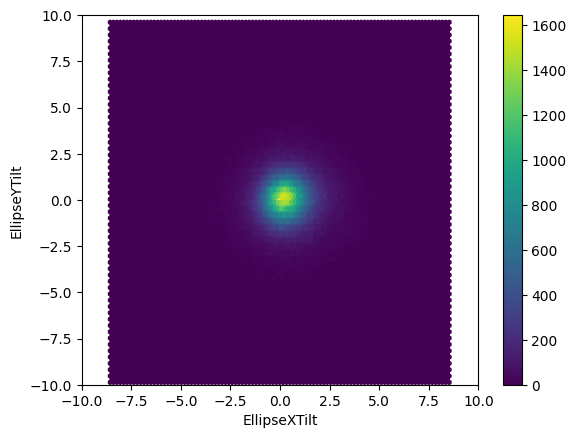

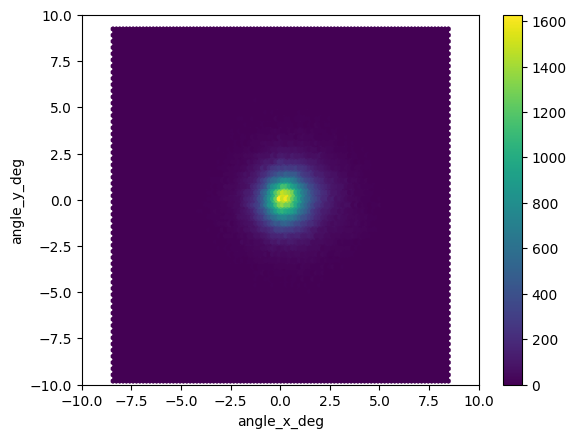

In [1]:
from main import *
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import subprocess

# create dataset
subprocess.run(["python", "main.py"])
z = 0

layer_tilts = data_sim_arr[i,z]
layer_tilts[0], y = make_blobs(
   n_samples=150, n_features=2,
   centers=3, cluster_std=0.5,
   shuffle=True, random_state=0
)

# plot
plt.scatter(
   X[:, 0], X[:, 1],
   c='white', marker='o',
   edgecolor='black', s=50
)
plt.show()

### Implement K-Means

In [2]:
from sklearn.cluster import KMeans

clusters = 3

km = KMeans(
    n_clusters=clusters, init='random',
    n_init=10, max_iter=300, 
    tol=1e-04, random_state=0
    )
y_km = km.fit_predict(X)

To visualize the result, we can plot the clusters and the centroids using MatPlotLib.

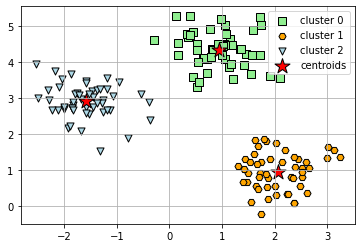

In [3]:
# plot the 3 clusters
colors = ['lightgreen', 'orange', 'lightblue', 'lightcoral', 'gold', 'plum', 'midnightblue', ' indigo', 'sandybrown']
markers = ['s', 'H', 'v', 'p', '^', 'o', 'X', 'd', 'P' ]

for i in range(clusters):
    plt.scatter(
        X[y_km == i, 0], X[y_km == i, 1],
        s=50, c=colors[i],
        marker=markers[i], edgecolor='black',
        label='cluster ' + str(i)
    )

# plot the centroids
plt.scatter(
    km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
    s=250, marker='*',
    c='red', edgecolor='black',
    label='centroids'
)
plt.legend(scatterpoints=1)
plt.grid()
plt.show()

### Elbow method
In order to determine the optimal *k* value, it is possible to use an elbow graph. This graph plots the number of clusters against the distortion. The optimal value for *k* is at the 'elbow' in the graph. In the graph below, for example we can see that it is 3.

C:\Users\lisam\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


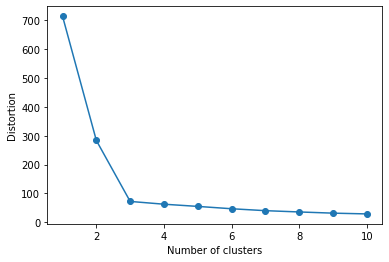

In [4]:
# calculate distortion for a range of number of cluster
distortions = []
for i in range(1, 11):
    km = KMeans(
        n_clusters=i, init='random',
        n_init=10, max_iter=300,
        tol=1e-04, random_state=0
    )
    km.fit(X)
    distortions.append(km.inertia_)

# plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

TASK: In the classifier below, set n_clusters to 4 by changing the value of the variable "clusters" to 4, and see how the clustering changes. 

In [ ]:
clusters = 3

km = KMeans(
    n_clusters=clusters, init='random',
    n_init=10, max_iter=300, 
    tol=1e-04, random_state=0
)
y_km = km.fit_predict(X)

In [ ]:
# plot the 3 clusters
colors = ['lightgreen', 'orange', 'lightblue', 'lightcoral', 'gold', 'plum', 'midnightblue', ' indigo', 'sandybrown']
markers = ['s', 'H', 'v', 'p', '^', 'o', 'X', 'd', 'P' ]

for i in range(clusters):
    plt.scatter(
        X[y_km == i, 0], X[y_km == i, 1],
        s=50, c=colors[i],
        marker=markers[i], edgecolor='black',
        label='cluster ' + str(i)
    )

# plot the centroids
plt.scatter(
    km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
    s=250, marker='*',
    c='red', edgecolor='black',
    label='centroids'
)
plt.legend(scatterpoints=1)
plt.grid()
plt.show()

TASK: Choose two features from the wine dataset which are appropriate for clustering and apply K-Means clustering on the data based on those two features. 

Don't forget to normalize the input data using a pipeline like we have done in previous notebooks. Check the SVM notebook for an example.

In [ ]:
# Complete the task here

### Conclusions
* K-means clusters data based on the distance of the data point to a centroid.
* K-means requires knowing how many clusters the result will have.
* The *k* centroids are randomly initialized, the points are grouped to the nearest centroid, the points are averaged and the centroid is moved to this new location. These steps are repeated until a stopping condition has been reached.
* The features need to be normalized before using them as an input, as it affects the performance of K-Means.
* K-Means does not perform well with non-spherical shapes, unless the data are appropriately transformed beforehand.